# **I. Procesamiento inicial: clasificación de pacientes oncológicos y grupo de control del GRD**

## Objetivo
Este notebook procesa los datos de episodios hospitalarios del sistema de Grupos Relacionados por el Diagnóstico (GRD) para identificar y clasificar a los pacientes con diagnóstico oncológico, conservando al resto de la población como grupo de control (`SIN_CANCER`). Esto evita sesgos de selección en el conjunto de datos y permite una correcta caracterización predictiva.

## Proceso
1. **Lectura de datos**: Carga archivos .txt del GRD público con diferentes codificaciones según el año (extraídos de datos abiertos de FONASA: https://public.tableau.com/views/PropuestaTableroGRD/PropuestaTableroGRD?%3AshowVizHome=no).
2. **Limpieza básica**: Exclusión de episodios que no poseen un diagnóstico principal registrado (`DIAGNOSTICO1` nulo).
3. **Clasificación y etiquetado**: Agrupa los códigos CIE-10 (Neoplasias Malignas) en 15 categorías según la localización del tumor. Cualquier otro diagnóstico principal fuera de este rango se cataloga bajo la etiqueta `SIN_CANCER`.
4. **Salidas**:
   - Archivos CSV con los datos etiquetados (en la carpeta: `Datos procesados`).
   - Tablas de frecuencias para análisis poblacional (en la carpeta de resultados: `Distribución de diagnósticos`).
   - Gráficos de distribución exclusivos de casos oncológicos para observar la prevalencia por tipo de cáncer (en la carpeta de resultados: `Distribución de diagnósticos`).

## Clasificación de Tipos de Cáncer y Control (CIE-10)
| Rango | Categoría |
|-------|-----------|
| C00-C14 | Labio, cavidad oral y faringe |
| C15-C26 | Órganos digestivos |
| C30-C39 | Órganos respiratorios e intratorácicos |
| C40-C41 | Hueso y cartílago articular |
| C43-C44 | Melanoma y otras neoplasias malignas de piel |
| C45-C49 | Tejidos mesoteliales y tejidos blandos |
| C50 | Mama |
| C51-C58 | Órganos genitales femeninos |
| C60-C63 | Órganos genitales masculinos |
| C64-C68 | Tracto urinario |
| C69-C72 | Ojo, cerebro y SNC |
| C73-C75 | Tiroides y otras glándulas endocrinas |
| C76-C80 | Localizaciones mal definidas y secundarias |
| C81-C96 | Tejidos linfoide, hematopoyético y relacionados |
| C97 | Múltiples localizaciones independientes |
| **N/A** | **SIN_CANCER (Grupo de control)** |

# **I. Procesamiento inicial: clasificación de pacientes oncológicos y grupo de control del GRD**

## Objetivo
Este notebook procesa los datos de episodios hospitalarios del sistema de Grupos Relacionados por el Diagnóstico (GRD) para identificar y clasificar a los pacientes con diagnóstico oncológico, conservando al resto de la población como grupo de control (`SIN_CANCER`). Esto evita sesgos de selección en el conjunto de datos, permite realizar una correcta selección de características (*Feature Selection*) mediante técnicas como *Bootstrapping*, y garantiza una caracterización retrospectiva íntegra.

## Proceso
1. **Lectura de datos**: Carga archivos .txt del GRD público con diferentes codificaciones según el año (extraídos de datos abiertos de FONASA).
2. **Limpieza básica**: Exclusión de episodios que no poseen un diagnóstico principal registrado (`DIAGNOSTICO1` nulo).
3. **Clasificación y etiquetado**: Agrupa los códigos CIE-10 (Neoplasias Malignas) en 15 categorías según la localización del tumor. Cualquier otro diagnóstico principal fuera de este rango se cataloga bajo la etiqueta `SIN_CANCER`.
4. **Salidas**:
   - Archivos CSV con los datos etiquetados (en la carpeta: `Datos clasificados`).
   - Tabla de frecuencias y proporciones para análisis poblacional (en la carpeta: `Resultados (etapa 1 y 2)`).
   - Gráficos comparativos de proporciones y distribución general de categorías para observar el desbalance de clases real del hospital.

## Clasificación de Tipos de Cáncer y Control (CIE-10)
| Rango | Categoría |
|-------|-----------|
| C00-C14 | Labio, cavidad oral y faringe |
| C15-C26 | Órganos digestivos |
| C30-C39 | Órganos respiratorios e intratorácicos |
| C40-C41 | Hueso y cartílago articular |
| C43-C44 | Melanoma y otras neoplasias malignas de piel |
| C45-C49 | Tejidos mesoteliales y tejidos blandos |
| C50 | Mama |
| C51-C58 | Órganos genitales femeninos |
| C60-C63 | Órganos genitales masculinos |
| C64-C68 | Tracto urinario |
| C69-C72 | Ojo, cerebro y SNC |
| C73-C75 | Tiroides y otras glándulas endocrinas |
| C76-C80 | Localizaciones mal definidas y secundarias |
| C81-C96 | Tejidos linfoide, hematopoyético y relacionados |
| C97 | Múltiples localizaciones independientes |
| **N/A** | **SIN_CANCER (Grupo de control)** |

In [1]:
# Librerías a utilizar 
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ==================== CONFIGURACIÓN INICIAL ====================
ruta_originales = '../../Datos/Datos originales/'
ruta_filtrados = '../../Datos/Datos clasificados/' 
ruta_resultados = '../../Resultados/Resultados (etapa 1 y 2)/Distribución de diagnósticos'

os.makedirs(ruta_filtrados, exist_ok=True)
os.makedirs(ruta_resultados, exist_ok=True)

# ==================== CONFIGURACIÓN POR AÑO ====================
datasets = {
    "2019": ("GRD_PUBLICO_2019.txt", "CIP_ENCRIPTADO", "latin1"),
    "2020": ("GRD_PUBLICO_2020.txt", "CIP_ENCRIPTADO", "latin1"),
    "2021": ("GRD_PUBLICO_2021.txt", "CIP_ENCRIPTADO", "latin1"),
    "2022": ("GRD_PUBLICO_2022.txt", "CIP_ENCRIPTADO", "utf-16"),
    "2023": ("GRD_PUBLICO_2023.txt", "CIP_ENCRIPTADO", "utf-16"),
    "2024": ("GRD_PUBLICO_2024.txt", "ID_BENEFICIARIO", "latin1"),
}

# ==================== FUNCIONES CLASIFICADORAS ====================
def clasificar_tipo_cancer(codigo):
    '''
    - Descripción: Clasifica el código CIE-10 en categoría oncológica o en 'SIN_CANCER'.
                   Retorna None solo si el código es nulo.
    '''
    if pd.isna(codigo):
        return None
        
    cod_base = str(codigo).split('.')[0].strip().upper()
    
    if not cod_base.startswith('C') or len(cod_base) < 3:
        return 'SIN_CANCER'
        
    try:
        num = int(cod_base[1:3])
        if 0 <= num <= 14: return 'C00-C14: Labio, cavidad oral y faringe'
        elif 15 <= num <= 26: return 'C15-C26: Órganos digestivos'
        elif 30 <= num <= 39: return 'C30-C39: Órganos respiratorios e intratorácicos'
        elif 40 <= num <= 41: return 'C40-C41: Hueso y cartílago articular'
        elif 43 <= num <= 44: return 'C43-C44: Melanoma y otras neoplasias malignas de piel'
        elif 45 <= num <= 49: return 'C45-C49: Tejidos mesoteliales y tejidos blandos'
        elif num == 50: return 'C50: Mama'
        elif 51 <= num <= 58: return 'C51-C58: Órganos genitales femeninos'
        elif 60 <= num <= 63: return 'C60-C63: Órganos genitales masculinos'
        elif 64 <= num <= 68: return 'C64-C68: Tracto urinario'
        elif 69 <= num <= 72: return 'C69-C72: Ojo, cerebro y SNC'
        elif 73 <= num <= 75: return 'C73-C75: Tiroides y otras glándulas endocrinas'
        elif 76 <= num <= 80: return 'C76-C80: Localizaciones mal definidas y secundarias'
        elif 81 <= num <= 96: return 'C81-C96: Tejidos linfoide, hematopoyético y relacionados'
        elif num == 97: return 'C97: Múltiples localizaciones independientes'
        else: return 'SIN_CANCER'
    except ValueError:
        return 'SIN_CANCER'

# ==================== PROCESAMIENTO PRINCIPAL ====================
for año, (archivo_entrada, id_columna, codificacion) in datasets.items():
    ruta_completa = os.path.join(ruta_originales, archivo_entrada)
    
    if not os.path.exists(ruta_completa):
        print(f"Archivo no encontrado: {archivo_entrada}. Saltando...")
        continue
        
    print(f"\n{'='*50}")
    print(f"--- Procesando Año {año} ---")
    print(f"{'='*50}")
    
    try:
        df = pd.read_csv(ruta_completa, sep='|', encoding=codificacion, low_memory=False, on_bad_lines='skip')
        total_inicial = len(df)
        
        # 1. Eliminar filas donde el Diagnóstico Principal es nulo (registro inválido)
        df_limpio = df[df['DIAGNOSTICO1'].notnull()].copy()
        
        # 2. Paso Inicial: Revisar DIAGNOSTICO1 (Cáncer Principal)
        df_limpio['CATEGORIA_CANCER'] = df_limpio['DIAGNOSTICO1'].apply(clasificar_tipo_cancer)
        
        # Creamos la nueva columna de tipo de diagnóstico
        df_limpio['TIPO_DIAGNOSTICO_ONCO'] = df_limpio['CATEGORIA_CANCER'].apply(
            lambda x: 'PRINCIPAL' if x != 'SIN_CANCER' else 'SIN_CANCER'
        )
        
        # 3. Paso Secundario: Escaneo de DIAGNOSTICO2 a DIAGNOSTICO35
        # Identificamos qué columnas secundarias existen realmente en este archivo
        cols_secundarias = [col for col in df_limpio.columns if col.startswith('DIAGNOSTICO') and col != 'DIAGNOSTICO1']
        
        print("Escaneando diagnósticos secundarios...")
        for col in cols_secundarias:
            # Solo revisamos a los pacientes que TODAVÍA siguen clasificados como SIN_CANCER
            mask_pendientes = df_limpio['TIPO_DIAGNOSTICO_ONCO'] == 'SIN_CANCER'
            
            # Si ya no quedan pacientes sin cáncer, detenemos el escáner
            if not mask_pendientes.any():
                break
                
            # Aplicamos la clasificación solo a esa columna para los pendientes
            clasificacion_temp = df_limpio.loc[mask_pendientes, col].apply(clasificar_tipo_cancer)
            
            # Identificamos los nuevos casos de cáncer descubiertos en esta columna
            mask_nuevos_cancer = (clasificacion_temp != 'SIN_CANCER') & (clasificacion_temp.notnull())
            idx_actualizar = clasificacion_temp[mask_nuevos_cancer].index
            
            # Actualizamos las variables maestras
            df_limpio.loc[idx_actualizar, 'CATEGORIA_CANCER'] = clasificacion_temp[mask_nuevos_cancer]
            df_limpio.loc[idx_actualizar, 'TIPO_DIAGNOSTICO_ONCO'] = 'SECUNDARIO'

        # 4. Reporte final del año
        total_validos = len(df_limpio)
        total_cancer_prin = len(df_limpio[df_limpio['TIPO_DIAGNOSTICO_ONCO'] == 'PRINCIPAL'])
        total_cancer_sec = len(df_limpio[df_limpio['TIPO_DIAGNOSTICO_ONCO'] == 'SECUNDARIO'])
        total_cancer = total_cancer_prin + total_cancer_sec
        total_sin_cancer = total_validos - total_cancer
        
        print(f"Filas iniciales: {total_inicial:,} | Filas válidas: {total_validos:,}")
        print(f"Pacientes SIN cáncer: {total_sin_cancer:,}")
        print(f"Pacientes CON cáncer: {total_cancer:,} ({(total_cancer/total_validos)*100:.2f}%)")
        print(f"  - Cáncer Principal: {total_cancer_prin:,}")
        print(f"  - Cáncer Secundario: {total_cancer_sec:,}")
        
        # 5. Guardar Dataset
        archivo_salida = os.path.join(ruta_filtrados, f'GRD_CLASIFICADO_{año}.csv')
        df_limpio.to_csv(archivo_salida, index=False, encoding='utf-8')
        print(f"Dataset clasificado guardado en: {archivo_salida}")
        
    except Exception as e:
        print(f"Error procesando el archivo del año {año}: {e}")

print("\nProceso de extracción y clasificación finalizado.")


--- Procesando Año 2019 ---
Escaneando diagnósticos secundarios...
Filas iniciales: 1,151,475 | Filas válidas: 1,151,398
Pacientes SIN cáncer: 1,053,569
Pacientes CON cáncer: 97,829 (8.50%)
  - Cáncer Principal: 46,241
  - Cáncer Secundario: 51,588
Dataset clasificado guardado en: ../../Datos/Datos clasificados/GRD_CLASIFICADO_2019.csv

--- Procesando Año 2020 ---
Escaneando diagnósticos secundarios...
Filas iniciales: 781,912 | Filas válidas: 781,911
Pacientes SIN cáncer: 716,985
Pacientes CON cáncer: 64,926 (8.30%)
  - Cáncer Principal: 35,294
  - Cáncer Secundario: 29,632
Dataset clasificado guardado en: ../../Datos/Datos clasificados/GRD_CLASIFICADO_2020.csv

--- Procesando Año 2021 ---
Escaneando diagnósticos secundarios...
Filas iniciales: 816,909 | Filas válidas: 816,909
Pacientes SIN cáncer: 748,983
Pacientes CON cáncer: 67,926 (8.32%)
  - Cáncer Principal: 38,836
  - Cáncer Secundario: 29,090
Dataset clasificado guardado en: ../../Datos/Datos clasificados/GRD_CLASIFICADO_2021

'C00-C14: Labio, cavidad oral y faringe', 'C15-C26: Órganos digestivos', 'C30-C39: Órganos respiratorios e intratorácicos', 'C40-C41: Hueso y cartílago articular', 'C43-C44: Melanoma y otras neoplasias malignas de piel', 'C45-C49: Tejidos mesoteliales y tejidos blandos', 'C50: Mama', 'C51-C58: Órganos genitales femeninos', 'C60-C63: Órganos genitales masculinos', 'C64-C68: Tracto urinario', 'C69-C72: Ojo, cerebro y SNC', 'C73-C75: Tiroides y otras glándulas endocrinas', 'C76-C80: Localizaciones mal definidas y secundarias', 'C81-C96: Tejidos linfoide, hematopoyético y relacionados', 'C97: Múltiples localizaciones independientes' y 'SIN_CANCER'

Calculando proporciones y acumulando categorías...

Tabla de proporciones guardada en: ../../Resultados/Resultados (etapa 1 y 2)\proporciones_cancer_vs_control.csv

--- Resumen de la cohorte ---


,Período,Cáncer Principal,% Principal,Cáncer Secundario,% Secundario,Sin Cáncer,% Sin Cáncer,Total Episodios
0,2019,"46,241",4.02%,"51,588",4.48%,"1,053,569",91.50%,"1,151,398"
1,2020,"35,294",4.51%,"29,632",3.79%,"716,985",91.70%,"781,911"
2,2021,"38,836",4.75%,"29,090",3.56%,"748,983",91.68%,"816,909"
3,2022,"44,827",4.81%,"33,242",3.56%,"854,768",91.63%,"932,837"
4,2023,"51,784",4.98%,"38,931",3.74%,"948,872",91.27%,"1,039,587"
5,2024,"55,111",5.08%,"44,042",4.06%,"986,660",90.87%,"1,085,813"
6,TOTAL GENERAL,"272,093",4.68%,"226,525",3.90%,"5,309,837",91.42%,"5,808,455"


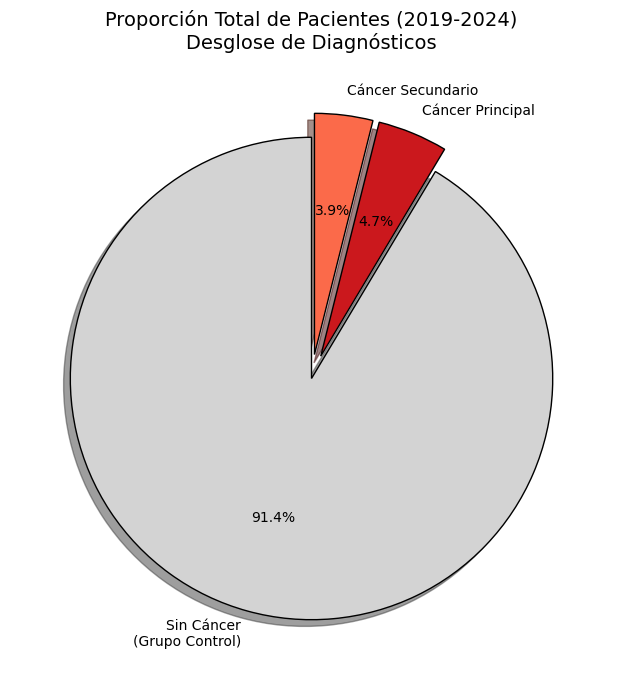

Gráfico circular guardado en: ../../Resultados/Resultados (etapa 1 y 2)\grafico_proporcion_total.png



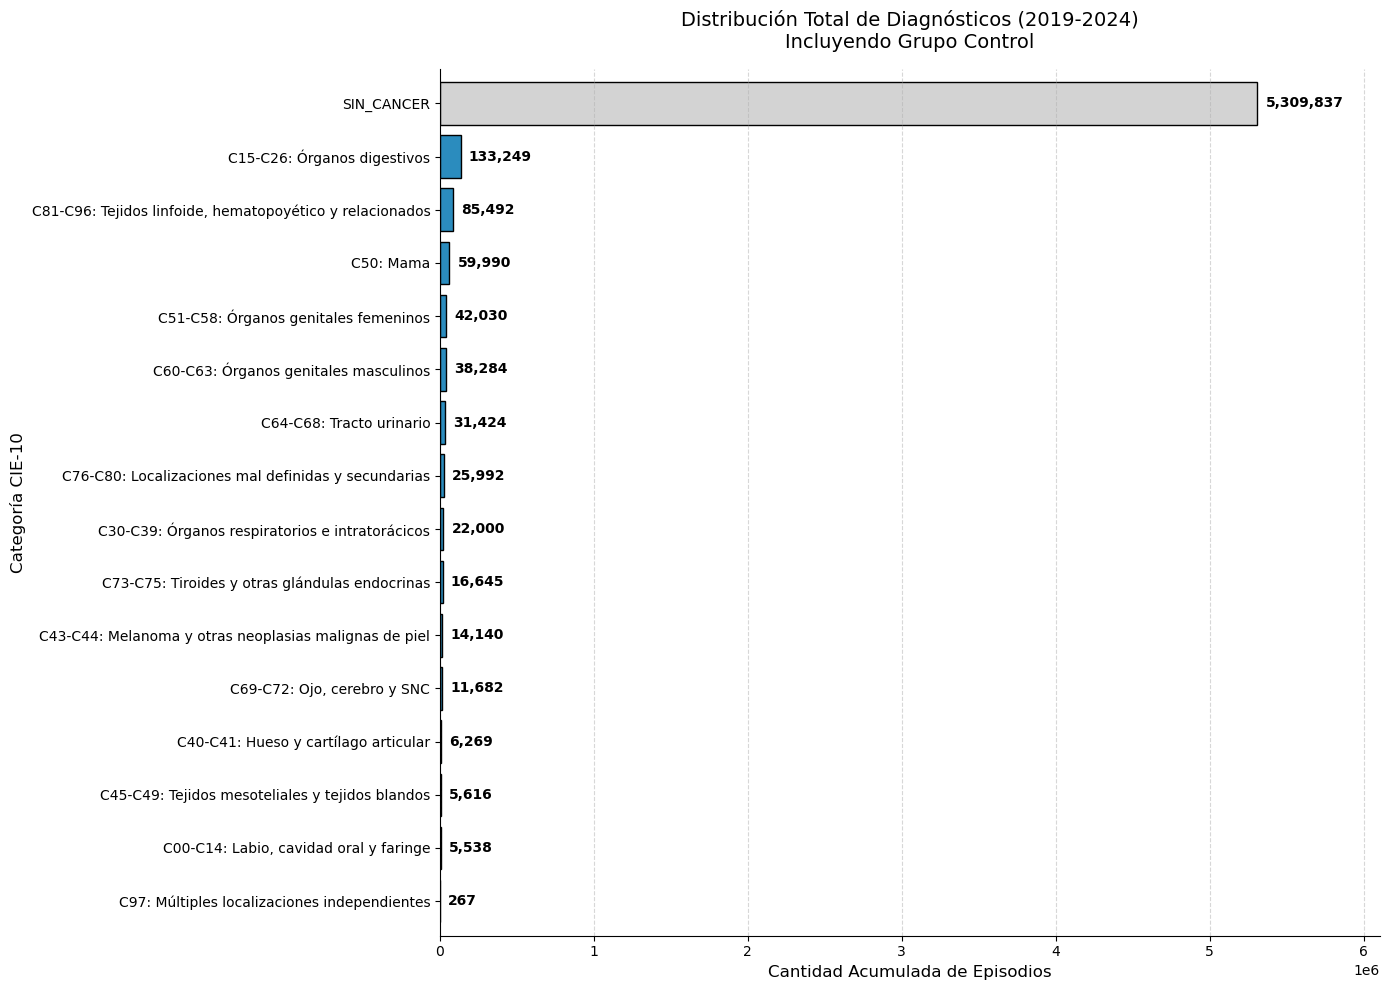

Gráfico de barras global guardado en: ../../Resultados/Resultados (etapa 1 y 2)\grafico_barras_total_categorias.png

¡Proceso finalizado exitosamente!


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from IPython.display import display

# Rutas y configuración
ruta_datos = '../../Datos/Datos clasificados/'
ruta_resultados = '../../Resultados/Resultados (etapa 1 y 2)'
os.makedirs(ruta_resultados, exist_ok=True)

años = ['2019', '2020', '2021', '2022', '2023', '2024']
resultados = []

# Contadores para el total general
total_gen_cancer_prin = 0
total_gen_cancer_sec = 0
total_gen_sin_cancer = 0

# Acumulador para las barras de categorías de todos los años
conteo_categorias_global = pd.Series(dtype=float)

print("Calculando proporciones y acumulando categorías...\n")

for año in años:
    archivo = os.path.join(ruta_datos, f'GRD_CLASIFICADO_{año}.csv')
    
    if os.path.exists(archivo):
        # Leer SOLO las columnas necesarias para no saturar memoria
        df = pd.read_csv(archivo, usecols=['CATEGORIA_CANCER', 'TIPO_DIAGNOSTICO_ONCO'], encoding='utf-8')
        
        # 1. ACUMULAR CATEGORÍAS PARA EL GRÁFICO GLOBAL DE BARRAS
        conteo_actual = df['CATEGORIA_CANCER'].value_counts()
        conteo_categorias_global = conteo_categorias_global.add(conteo_actual, fill_value=0)
        
        # 2. CÁLCULO DE PROPORCIONES (3 CATEGORÍAS)
        total_año = len(df)
        sin_cancer = len(df[df['TIPO_DIAGNOSTICO_ONCO'] == 'SIN_CANCER'])
        cancer_prin = len(df[df['TIPO_DIAGNOSTICO_ONCO'] == 'PRINCIPAL'])
        cancer_sec = len(df[df['TIPO_DIAGNOSTICO_ONCO'] == 'SECUNDARIO'])
        
        total_gen_cancer_prin += cancer_prin
        total_gen_cancer_sec += cancer_sec
        total_gen_sin_cancer += sin_cancer
        
        pct_prin = (cancer_prin / total_año) * 100 if total_año > 0 else 0
        pct_sec = (cancer_sec / total_año) * 100 if total_año > 0 else 0
        pct_sin = (sin_cancer / total_año) * 100 if total_año > 0 else 0
        
        resultados.append({
            'Período': año,
            'Cáncer Principal': cancer_prin,
            '% Principal': f"{pct_prin:.2f}%",
            'Cáncer Secundario': cancer_sec,
            '% Secundario': f"{pct_sec:.2f}%",
            'Sin Cáncer': sin_cancer,
            '% Sin Cáncer': f"{pct_sin:.2f}%",
            'Total Episodios': total_año
        })
    else:
        print(f"No se encontró el archivo: {archivo}")

# Agregar la fila del Total General a la tabla
total_general = total_gen_cancer_prin + total_gen_cancer_sec + total_gen_sin_cancer
if total_general > 0:
    pct_gen_prin = (total_gen_cancer_prin / total_general) * 100
    pct_gen_sec = (total_gen_cancer_sec / total_general) * 100
    pct_gen_sin = (total_gen_sin_cancer / total_general) * 100
    
    resultados.append({
        'Período': 'TOTAL GENERAL',
        'Cáncer Principal': total_gen_cancer_prin,
        '% Principal': f"{pct_gen_prin:.2f}%",
        'Cáncer Secundario': total_gen_cancer_sec,
        '% Secundario': f"{pct_gen_sec:.2f}%",
        'Sin Cáncer': total_gen_sin_cancer,
        '% Sin Cáncer': f"{pct_gen_sin:.2f}%",
        'Total Episodios': total_general
    })

df_resultados = pd.DataFrame(resultados)

# --- EXPORTAR Y MOSTRAR LA TABLA ---
archivo_csv = os.path.join(ruta_resultados, 'proporciones_cancer_vs_control.csv')
df_resultados.to_csv(archivo_csv, index=False, encoding='utf-8-sig')

# Aplicar separador de miles para la visualización en Jupyter
df_formateado = df_resultados.copy()
for col in ['Cáncer Principal', 'Cáncer Secundario', 'Sin Cáncer', 'Total Episodios']:
    df_formateado[col] = df_formateado[col].apply(lambda x: f"{x:,}")

print(f"Tabla de proporciones guardada en: {archivo_csv}")
print("\n--- Resumen de la cohorte ---")
display(df_formateado)

# --- GRÁFICO 1: CIRCULAR (PIE CHART - 3 CATEGORÍAS) ---
if total_general > 0:
    plt.figure(figsize=(9, 7))
    etiquetas = ['Sin Cáncer\n(Grupo Control)', 'Cáncer Principal', 'Cáncer Secundario']
    valores = [total_gen_sin_cancer, total_gen_cancer_prin, total_gen_cancer_sec]
    
    # Colores: Gris (Control), Rojo oscuro (Principal), Naranja/Rojo claro (Secundario)
    colores_pie = ['#d3d3d3', '#cb181d', '#fb6a4a']
    
    # Separamos un poco las dos porciones de cáncer para destacarlas
    explode = (0, 0.1, 0.1) 
    
    plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=90, 
            colors=colores_pie, explode=explode, shadow=True, 
            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
    plt.title('Proporción Total de Pacientes (2019-2024)\nDesglose de Diagnósticos', fontsize=14, pad=20)
    
    archivo_pie = os.path.join(ruta_resultados, 'grafico_proporcion_total.png')
    plt.tight_layout()
    plt.savefig(archivo_pie, dpi=300)
    plt.show()
    print(f"Gráfico circular guardado en: {archivo_pie}\n")

# --- GRÁFICO 2: BARRAS HORIZONTALES GLOBAL (ESCALA LINEAL CON NÚMEROS) ---
if not conteo_categorias_global.empty:
    plt.figure(figsize=(14, 10)) 
    
    conteo_categorias_global = conteo_categorias_global.sort_values(ascending=True)
    
    colores_barras = ['#d3d3d3' if cat == 'SIN_CANCER' else '#2b8cbe' for cat in conteo_categorias_global.index]
    
    ax = conteo_categorias_global.plot(kind='barh', color=colores_barras, edgecolor='black', width=0.8)
    
    max_val = conteo_categorias_global.max()
    for i, v in enumerate(conteo_categorias_global):
        ax.text(v + (max_val * 0.01), i, f"{int(v):,}", color='black', va='center', fontsize=10, fontweight='bold')
    
    plt.title('Distribución Total de Diagnósticos (2019-2024)\nIncluyendo Grupo Control', fontsize=14, pad=15)
    plt.xlabel('Cantidad Acumulada de Episodios', fontsize=12)
    plt.ylabel('Categoría CIE-10', fontsize=12)
    
    ax.set_xlim(0, max_val * 1.15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    archivo_barras = os.path.join(ruta_resultados, 'grafico_barras_total_categorias.png')
    plt.savefig(archivo_barras, dpi=300)
    plt.show()
    print(f"Gráfico de barras global guardado en: {archivo_barras}")

print("\n¡Proceso finalizado exitosamente!")